In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Task 1**

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
#Fetching the data
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
df.describe()

Checking Anamoly

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values")

We know that longitude can have negative values. So, that must not be the problem. we can also check anamoly through the use of inter quartile range


In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers ")

# Task 2



In [ ]:
df['MedHouseVal'] = housing.target

In [ ]:
df_clean = df.copy()

print(f"Missing Values before Cleaning {df_clean.isnull().sum().sum()}")

In [ ]:
df_clean.head()

No missing values, so no need for dropping or imputing missing values. But from the above result, we can see clearly that there are outliers in 5 features. So, we can take them as inconsistent values and work on them.

In [ ]:
outlier_cols = ['MedInc', 'AveRooms', 'AveBedrms', 'AveOccup', 'Population']
total_rows = len(df_clean)

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    removed = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]

print(f"Rows before cleaning {total_rows}")
print(f"Rows after cleaning {len(df_clean)}")
print(f"Rows removed {total_rows - len(df_clean)}")

In [ ]:
df_clean.shape

# Task 3


In [ ]:
fig = plt.figure(figsize=(20, 15))


plt.subplot(3, 3, 1)

plt.hist(df_clean['MedHouseVal'], bins=50, alpha=0.7)
plt.title('Median House Value Dist')
plt.xlabel('Value ($100,000s)')
plt.ylabel('Frequency')
plt.axvline(df_clean['MedHouseVal'].median(), color='red', linestyle='--',
            label=f'Median: {df_clean["MedHouseVal"].median():.2f}')
plt.legend()

In [ ]:

plt.subplot(3, 3, 2)
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')


In [ ]:

plt.subplot(3, 3, 3)
plt.scatter(df_clean['MedInc'], df_clean['MedHouseVal'], alpha=0.3, s=10)
plt.title('Median Income vs House Value')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')

In [ ]:
plt.subplot(3, 3, 4)
plt.boxplot(df_clean['HouseAge'])
plt.title('House Age Distribution')
plt.xlabel('Age (years)')


In [ ]:
plt.subplot(3, 3, 5)
plt.scatter(df_clean['AveRooms'], df_clean['MedHouseVal'], alpha=0.3, s=10)
plt.title('Average Rooms vs House Value')
plt.xlabel('Average Rooms')
plt.ylabel('Median House Value')

In [ ]:
plt.subplot(3, 3, 6)
plt.scatter(df_clean['Population'], df_clean['MedHouseVal'], alpha=0.3, s=10)
plt.title('Population vs House Value')
plt.xlabel('Population')
plt.ylabel('Median House Value')

In [ ]:
plt.subplot(3, 3, 7)
key_features = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']
sns.pairplot(df_clean[key_features].sample(500))
plt.suptitle('Pairplot of Key Features', y=0.98)

In [ ]:
plt.subplot(3, 3, 8)
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr]
plt.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)
plt.title('Correlation with House Value')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()


***From here, we can see that the feature with the highest correlation with the value of the house seems to be MedInc and AveRooms.***

In [ ]:
plt.subplot(3, 3, 9)
scatter = plt.scatter(df_clean['Longitude'], df_clean['Latitude'],
                     c=df_clean['MedHouseVal'], alpha=0.5)
plt.title('Geographic Distribution of House Values')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label='House Value')
plt.tight_layout()
plt.show()

# Task 4


In [ ]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df_clean.copy()

df_encoded['IncomeCategory'] = pd.cut(df_encoded['MedInc'],
                                       bins=[0, 3, 6, 10, 15],
                                       labels=['Low', 'Medium', 'High', 'Very High'])


df_encoded['HouseAgeCategory'] = pd.cut(df_encoded['HouseAge'],
                                         bins=[0, 10, 30, 50, 100],
                                         labels=['New', 'Medium', 'Old', 'Very Old'])

df_encoded['LocationCategory'] = pd.cut(df_encoded['Latitude'],
                                         bins=[32, 35, 38, 42],
                                         labels=['South', 'Central', 'North'])

for col in ['IncomeCategory', 'HouseAgeCategory', 'LocationCategory']:
    print(f"\n{col}:")
    print(df_encoded[col].value_counts())

#Label Encoding
label_encoders = {}
ordinal_cols = ['IncomeCategory', 'HouseAgeCategory', 'LocationCategory']

for col in ordinal_cols:
    le = LabelEncoder()
    df_encoded[f'{col}_encoded'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"Label Encoded {col}:{le.classes_}")

# We can also use one hot encoding
df_onehot = pd.get_dummies(df_encoded,
                          columns=['IncomeCategory', 'HouseAgeCategory', 'LocationCategory'],
                          prefix=['Income', 'Age', 'Location'],
                          drop_first=True)


In [ ]:
df_onehot.shape, df_encoded.shape


## Clearly new columns are added due to encoding

# Task 5


In [ ]:
from sklearn.model_selection import train_test_split

X = df_onehot.drop('MedHouseVal', axis=1)
y = df_onehot['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [ ]:
X_train.shape, X_test.shape

Here, we are splitting the dataset with 80% training set and 20% test dataset. This is normally used split ratio, also the dataset consists of more than 19000 records, so about 3800 with test dataset is enough for the dataset to be tested on unseen data.

In [ ]:
X_train.head()

# Task 6


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f"Intercept {lr.intercept_:.4f}")
print(f"Coefficients:{coef_df.to_string(index=False)}")


Here, the negative coeffiencient that we get here shows the features that increases the house prices, and negative shows those which decrease prices. if the value is more that means the power of increasing or decreasing is even more strong.

# Task 7

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"RMS: {rmse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")

# Task 8


In [185]:
from sklearn.tree import DecisionTreeRegressor

depths = list(range(1, 21))
train_r2_list, test_r2_list = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_r2_list.append(r2_score(y_train, dt.predict(X_train)))
    test_r2_list.append(r2_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(test_r2_list)]
dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)

print(f"Best max_depth (highest test R2) : {best_depth}")
print(f"Train R2 at best depth : {train_r2_list[best_depth-1]:.4f}")
print(f"Test  R2 at best depth : {test_r2_list[best_depth-1]:.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_dt):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.4f}")


Best max_depth (highest test R2) : 10
Train R2 at best depth : 0.8440
Test  R2 at best depth : 0.7147
MAE  : 0.4084
RMSE : 0.6106


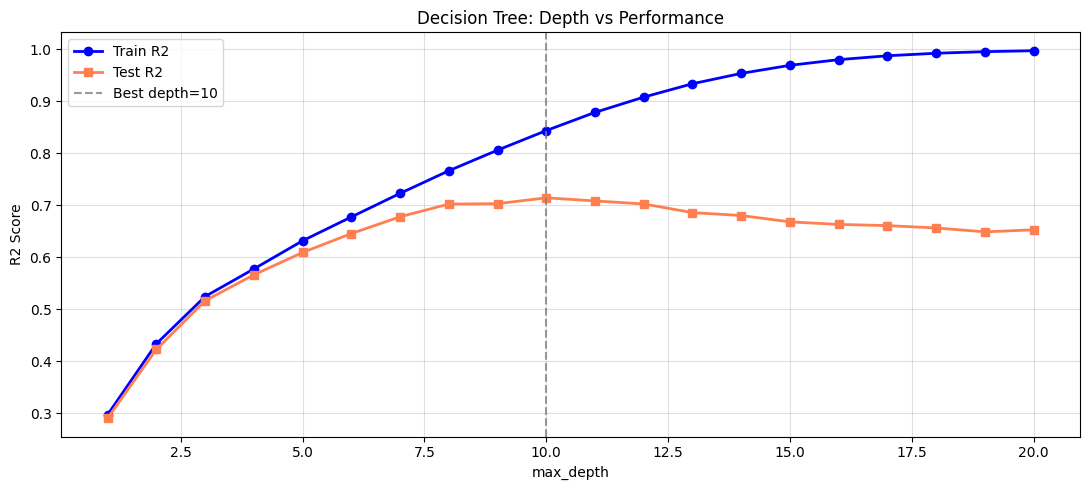

In [186]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, train_r2_list, 'o-',label='Train R2',color='blue', lw=2)
ax.plot(depths, test_r2_list,  's-',label='Test R2',color='coral',lw=2)
ax.axvline(best_depth, linestyle='--',color='gray',alpha=0.8,label=f'Best depth={best_depth}')
ax.set_xlabel("max_depth")
ax.set_ylabel("R2 Score")
ax.set_title("Decision Tree: Depth vs Performance")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()

# Task 9


In [187]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"{'Feature':<12} {'Mean (train)':<15} {'Std (train)'}")
for i, feat in enumerate(X.columns):
    print(f"  {feat:<12} {scaler.mean_[i]:>12.4f}   {scaler.scale_[i]:.4f}")

lr_sc = LinearRegression()
lr_sc.fit(X_train_sc,y_train)
y_pred_lr_sc = lr_sc.predict(X_test_sc)
r2_lr_sc = r2_score(y_test,y_pred_lr_sc)


Feature      Mean (train)    Std (train)
  MedInc             3.8264   1.7325
  HouseAge          29.1415   12.3852
  AveRooms           5.2150   1.1590
  AveBedrms          1.0530   0.0791
  Population      1344.2820   781.0782
  AveOccup           2.9061   0.7124
  Latitude          35.6214   2.1232
  Longitude       -119.5974   1.9945
  IncomeCategory_encoded       1.4452   0.6844
  HouseAgeCategory_encoded       1.0870   1.0596
  LocationCategory_encoded       1.2343   0.8971
  Income_Medium       0.5306   0.4991
  Income_High        0.1022   0.3030
  Income_Very High       0.0084   0.0915
  Age_Medium         0.4561   0.4981
  Age_Old            0.4119   0.4922
  Age_Very Old       0.0656   0.2475
  Location_Central       0.3127   0.4636
  Location_North       0.1403   0.3473


In [188]:
print(f"Without scaling R2={r2_lr:.4f}")
print(f"With scaling R2={r2_lr_sc:.4f} ")
print(f"Decision Tree (depth={best_depth})")
print(f"R2={test_r2_list[best_depth-1]:.4f}")

Without scaling R2=0.6983
With scaling R2=0.6983 
Decision Tree (depth=10)
R2=0.7147


# Task 10


In [189]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn = KNeighborsRegressor()
grid = GridSearchCV(
    knn, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid.fit(X_train_sc, y_train)

best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_sc)


In [190]:
print(f"  Best Parameters : {grid.best_params_}")
print(f" CV R2 {grid.best_score_:.4f}")
print(f" Test R2 {r2_score(y_test, y_pred_knn):.4f}")
print(f"Test MAE {mean_absolute_error(y_test, y_pred_knn):.4f}")
print(f"Test RMSE  {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.4f}")


  Best Parameters : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
 CV R2 0.7268
 Test R2 0.7463
Test MAE 0.4051
Test RMSE  0.5758


# Task 11


In [191]:
import joblib

joblib.dump(best_knn, "best_model_knn.joblib")
joblib.dump(scaler,   "scaler.joblib")

loaded_model  = joblib.load("best_model_knn.joblib")
loaded_scaler = joblib.load("scaler.joblib")

y_reload = loaded_model.predict(loaded_scaler.transform(X_test))
match = np.allclose(y_pred_knn, y_reload)


In [192]:
r2_score(y_test, y_reload)

0.746325661262409

# Task 12


In [199]:
base_features = {
    'MedInc': np.random.uniform(0.5, 15, 100),
    'HouseAge': np.random.uniform(1, 52, 100),
    'AveRooms': np.random.uniform(1, 15, 100),
    'AveBedrms': np.random.uniform(0.5, 5, 100),
    'Population': np.random.uniform(3, 35000, 100),
    'AveOccup': np.random.uniform(1, 10, 100),
    'Latitude': np.random.uniform(32.5, 42, 100),
    'Longitude': np.random.uniform(-124.3, -114.3, 100),
}

unseen_data = pd.DataFrame(base_features)

unseen_data['IncomeCategory'] = pd.cut(
    unseen_data['MedInc'],
    bins=[0,3,6,10,15],
    labels=['Low','Medium','High','Very High']
)
unseen_data['HouseAgeCategory'] = pd.cut(
    unseen_data['HouseAge'],
    bins=[0, 10, 30, 50, 100],
    labels=['New', 'Medium', 'Old', 'Very Old']
)

unseen_data['LocationCategory'] = pd.cut(
    unseen_data['Latitude'],
    bins=[32, 35, 38, 42],
    labels=['South','Central','North']
)

unseen_data = pd.get_dummies(
    unseen_data,
    columns=['IncomeCategory', 'HouseAgeCategory', 'LocationCategory'],
    prefix=['Income', 'Age', 'Location'],
    drop_first=True
)

unseen_data = unseen_data.reindex(columns=X.columns, fill_value=0)

unseen_scaled = loaded_scaler.transform(unseen_data)
unseen_preds = loaded_model.predict(unseen_scaled)


unseen_data['Predicted_$100k'] = unseen_preds.round(3)
unseen_data['Predicted_USD'] = (unseen_preds * 100_000).astype(int)

print(unseen_data[['MedInc','HouseAge','Latitude','Longitude',
                   'Predicted_$100k','Predicted_USD']].head(10).to_string(index=False))

   MedInc  HouseAge  Latitude   Longitude  Predicted_$100k  Predicted_USD
12.797279 41.659898 39.949619 -120.936700            4.723         472309
12.677643 14.717642 33.887841 -123.770972            4.739         473851
11.417977 30.064053 41.658383 -117.934378            4.700         469978
 6.985876 37.124097 41.700870 -122.647673            3.090         309033
 2.080189 41.739818 32.583502 -122.865719            1.287         128733
 7.316555 22.563180 41.334072 -115.899841            3.260         325972
13.503005 47.242137 36.837141 -119.592685            4.626         462593
14.295429  9.914532 40.716458 -115.781625            4.475         447548
 8.974917 33.910451 35.181099 -117.747362            4.782         478211
13.215568 41.584858 41.532511 -124.257943            4.536         453613


# Task 13


In [203]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['Latitude','Longitude','MedInc','MedHouseVal']
X_cluster = df_clean[cluster_features].sample(5000, random_state=42).reset_index(drop=True)
sc_cluster = StandardScaler()
X_cluster_sc = sc_cluster.fit_transform(X_cluster)

inertias, sil_scores = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_sc, labels))

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best k : {best_k}")
print(f"Silhouette scores: { {k: round(s,3) for k, s in zip(K_range, sil_scores)} }")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X_cluster['Cluster'] = km_final.fit_predict(X_cluster_sc)

summary = X_cluster.groupby('Cluster').agg(
    Count= ('MedInc', 'count'),
    AvgIncome = ('MedInc','mean'),
    AvgHouseVal= ('MedHouseVal','mean'),
    AvgLat= ('Latitude','mean'),
    AvgLon= ('Longitude','mean')
).round(3)
print(summary.to_string())



Best k : 3
Silhouette scores: {2: np.float64(0.436), 3: np.float64(0.444), 4: np.float64(0.414), 5: np.float64(0.348), 6: np.float64(0.316), 7: np.float64(0.327), 8: np.float64(0.331), 9: np.float64(0.314)}
         Count  AvgIncome  AvgHouseVal  AvgLat   AvgLon
Cluster                                                
0          836      6.507        3.940  35.343 -119.753
1         1761      3.303        1.630  38.000 -121.686
2         2403      3.300        1.735  33.943 -117.982


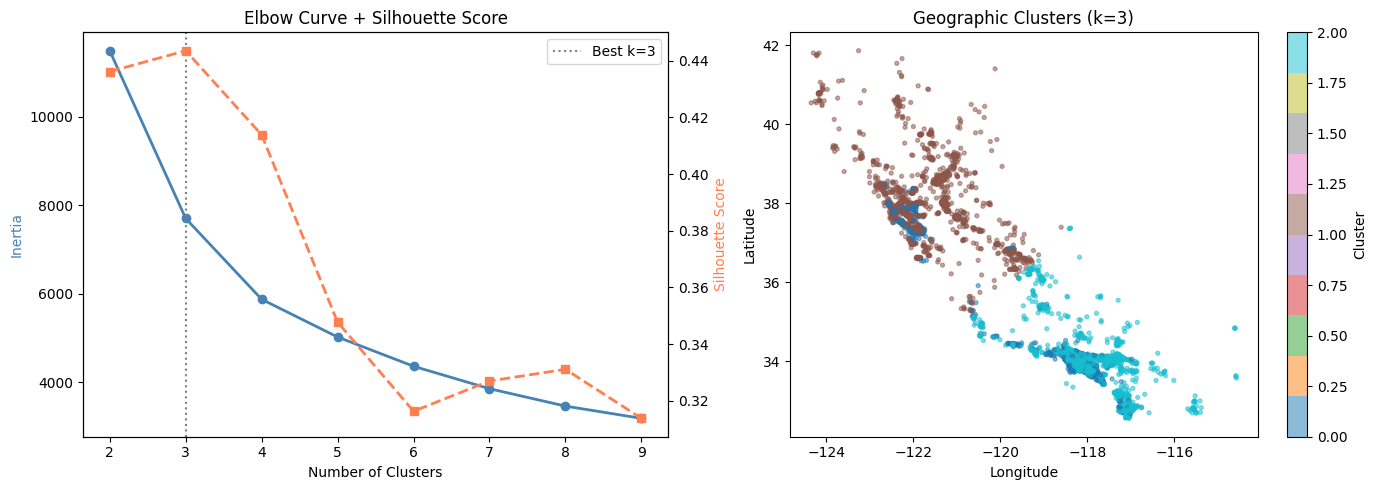

In [202]:
fig, axes = plt.subplots(1,2,figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-',color='steelblue', lw=2)
ax_sil = axes[0].twinx()
ax_sil.plot(list(K_range),sil_scores,'s--', color='coral', lw=2)
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia",color='blue')
ax_sil.set_ylabel("Silhouette Score",color='coral')
axes[0].set_title("Elbow Curve + Silhouette Score")
axes[0].axvline(best_k, color='gray',linestyle=':', label=f'Best k={best_k}')
axes[0].legend(loc='upper right')

sc_plot = axes[1].scatter(X_cluster['Longitude'], X_cluster['Latitude'],
                           c=X_cluster['Cluster'], cmap='tab10', alpha=0.5, s=8)
plt.colorbar(sc_plot, ax=axes[1], label="Cluster")
axes[1].set_title(f"Geographic Clusters (k={best_k})")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("clustering.png", dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# Task 14


In [205]:
results = {
    'Linear Regression': {
        'R2':   r2_score(y_test, y_pred_lr),
        'MAE':  mean_absolute_error(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr))
    },
    'Decision Tree': {
        'R2':   r2_score(y_test, y_pred_dt),
        'MAE':  mean_absolute_error(y_test, y_pred_dt),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dt))
    },
    'KNN(Tuned)': {
        'R2':   r2_score(y_test, y_pred_knn),
        'MAE':  mean_absolute_error(y_test, y_pred_knn),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_knn))
    }
}

                       R2     MAE    RMSE  Rank
KNN(Tuned)         0.7463  0.4051  0.5758     1
Decision Tree      0.7147  0.4084  0.6106     2
Linear Regression  0.6983  0.4621  0.6279     3
Best Model: KNN(Tuned)  (R2=0.7463)


/tmp/ipykernel_680/2238286510.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(model_names, rotation=15, ha='right')
/tmp/ipykernel_680/2238286510.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(model_names, rotation=15, ha='right')
/tmp/ipykernel_680/2238286510.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(model_names, rotation=15, ha='right')


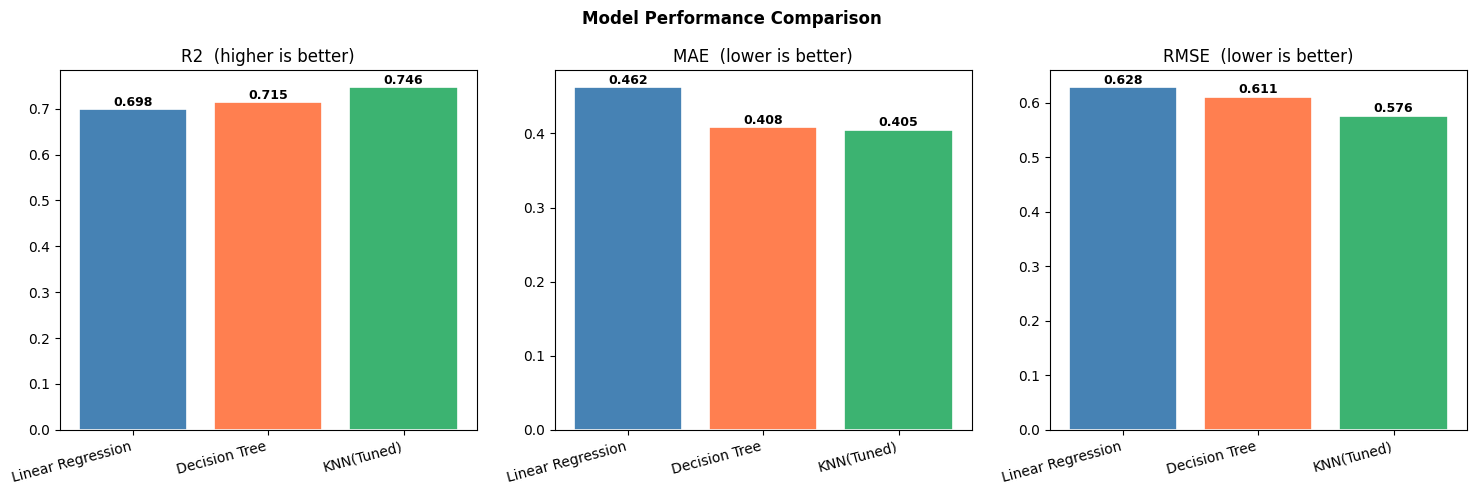

In [206]:
results_df = pd.DataFrame(results).T.round(4)
results_df['Rank'] = results_df['R2'].rank(ascending=False).astype(int)
print(f"{results_df.sort_values('R2', ascending=False).to_string()}")

best_model_name = results_df['R2'].idxmax()
print(f"Best Model: {best_model_name}  (R2={results[best_model_name]['R2']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Performance Comparison",fontweight='bold')

model_names = list(results.keys())
colors = ['blue','coral','mediumseagreen']

for i, (metric, direction) in enumerate(zip(['R2','MAE','RMSE'],
                                             ['higher is better', 'lower is better','lower is better'])):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f"{metric}  ({direction})")
    axes[i].set_xticklabels(model_names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.01,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# 15


In [208]:
best_model_name

'KNN(Tuned)'

In [209]:
results[best_model_name]['R2'], results[best_model_name]['RMSE']

(0.746325661262409, np.float64(0.5757850496248801))

Here, we can see that the best model that got the best result is K Nearest Neighbours, where we had also used hyperparameter tuning.

This can be considered as the best model for this use because it got the best R2 score with 0.74, which is the highest  and the RMSE score of 0.54, which is the lowest. So, this gives the conclusion that the best performing model is **Tuned KNN**.

Although, KNN seems to be the best one, we can see the result of other ones differ by just little, and not too worse.



Talking about tradeoffs,

Linear regression assumes linear relationships that are often unrealistic in this kind of scenario where the house price is to be predictd, and hence we can see that the LInear Regression model is worst of all here.

Decisison Tree are capable to model non-linear relationships. But as we see, they are unstable and is very prone to overfitting. This seems to be the second best model here.

For KNN, it performs well here because it is the non-parametric model  and makes no strict assumption about the distribution. But, it requires feature scaling and is slower during infrerence.